<a href="https://colab.research.google.com/github/kaxmarc/statistics_ml/blob/main/in_class_assignment/FIN_Practical_Exercise_2_%E2%80%93_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# In-Class Assignment 1: Data Preprocessing
**Week 2** (see also page 39 in the script)

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Step 1: Handling Missing Values

Identify columns that contain missing values.

Choose an appropriate strategy for each case:

Numerical features: mean or median imputation

Categorical features: mode imputation

Explain briefly why you chose each method.

📌 Hint: Use isnull(), sum(), and simple imputation methods.

In [55]:
# Load titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/kaxmarc/statistics_ml/refs/heads/main/datasets/train.csv') # RAW Data from my GitHub Repo

# df.info()

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Median imputation numerical features
numerical_columns = df.select_dtypes(include='number').columns
print(numerical_columns)

for feature in numerical_columns:
  if df[feature].isnull().sum() > 0:
    df[feature] = df[feature].fillna(df[feature].median())

# Modus imputation categorical features
categorical_columns = df.select_dtypes(exclude='number').columns
for feature in categorical_columns:
  if df[feature].isnull().sum() > 0:
    mode_temp = df[feature].mode()[0]
    df[feature] = df[feature].fillna(mode_temp)

# Adjusted features
print("\nAdjusted features:")
print(df.isnull().sum())



Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

Adjusted features:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


Explanation:

The numerical distribution is less symmetrical and contains outliers (very young/old), which makes the use of the median more appropriate.

Mode makes sense in categorical features, as it represents frequent value.

# Step 2: Noise Detection and Handling

Select one numerical feature.

Add artificial noise (small random variations) to this feature.

Apply a simple noise-handling technique, such as:

Moving average

Smoothing by aggregation

Compare the feature before and after noise handling.

📌 Goal: Understand the difference between raw and cleaned signals.

In [56]:
# Load titanic dataset (already loaded at start -> df)
#df = pd.read_csv('https://raw.githubusercontent.com/kaxmarc/statistics_ml/refs/heads/main/datasets/train.csv') # RAW Data from GitHub

# numerical feature: Fare (ticket price)
signal = df['Fare'].copy()

# Add artificial noise (small random variations) to this feature. "Reproducible"
np.random.seed(42)
noise = np.random.normal(loc=0, scale=1, size=len(signal))

# Apply a simple noise-handling technique, Smoothing by aggregation
signal_noisy = signal + noise
signal_smoothed = signal_noisy.rolling(window=4, min_periods=1).mean() # Slight smoothing (4) and without NaN (1)

comparison_df = pd.DataFrame({
  'Orig. signal': signal,
  'Noisy': signal_noisy,
  'Smoothed': signal_smoothed

})

print(comparison_df.head(20))

    Orig. signal      Noisy   Smoothed
0         7.2500   7.746714   7.746714
1        71.2833  71.145036  39.445875
2         7.9250   8.572689  29.154813
3        53.1000  54.623030  35.521867
4         8.0500   7.815847  35.539150
5         8.4583   8.224163  19.808932
6        51.8625  53.441713  31.026188
7        21.0750  21.842435  22.831039
8        11.1333  10.663826  23.543034
9        30.0708  30.613360  29.140333
10       16.7000  16.236582  19.839051
11       26.5500  26.084270  20.899510
12        8.0500   8.291962  20.306544
13       31.2750  29.361720  19.993634
14        7.8542   6.129282  17.466809
15       16.0000  15.437712  14.805169
16       29.1250  28.112169  19.760221
17       13.0000  13.314247  15.748353
18       18.0000  17.091976  18.489026
19        7.2250   5.812696  16.082772


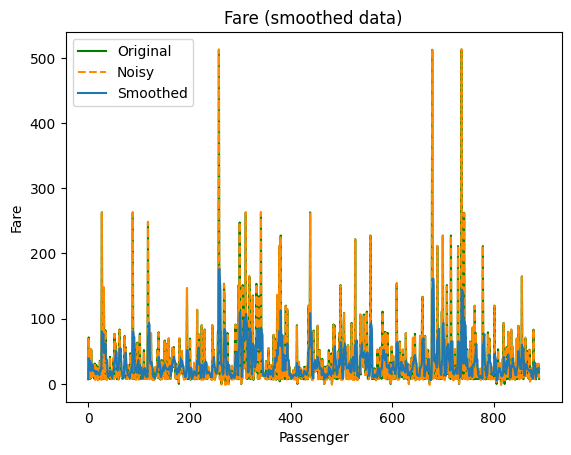

In [57]:
# Plot, for overview and determination smoothing window, without losing information.

plt.plot(signal, color='green', label='Original')
plt.plot(signal_noisy, color='darkorange', linestyle='--', label='Noisy')
plt.plot(signal_smoothed, label='Smoothed')
plt.title('Fare (smoothed data)')
plt.xlabel('Passenger')
plt.ylabel('Fare')
plt.legend()
plt.show()

Conclusion:

The aim is to attenuate outliers in the effect in order to better interpret the "signal". It is important not to completely "smooth" the noise, as otherwise information may be lost or the interpretation may be distorted.

# Step 3: Outlier Detection and Handling

Detect outliers in at least one numerical feature using:

Z-score method or

Visualization (boxplot)

Handle outliers by:

Removing them or

Transforming the feature

Justify your decision in 1–2 sentences.

In [58]:
# Load titanic dataset (already loaded at start -> df)
#df = pd.read_csv('https://raw.githubusercontent.com/kaxmarc/statistics_ml/refs/heads/main/datasets/train.csv') # RAW Data from GitHub

df['Fare_z_score'] = zscore(df['Fare'])

outliers = df[np.abs(df['Fare_z_score']) > 3] # Outliers (> 99,7% der normal distribution)

print("Outliers:", len(outliers))

Outliers: 20


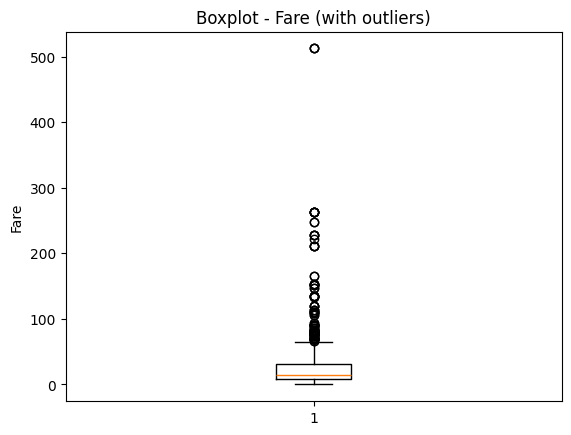

In [59]:
plt.boxplot(df['Fare'])
plt.title('Boxplot - Fare (with outliers)')
plt.ylabel('Fare')
plt.show()

Deleted outliers: 20


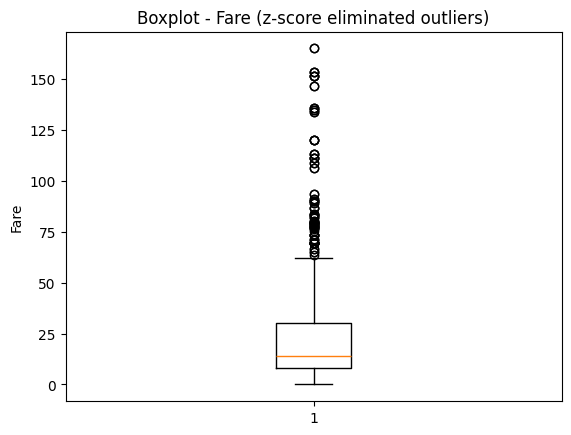

In [60]:
# Delete outliers using z-score

threshold = 3   # Outliers (> 99,7% der normal distribution)

df_no_outliers = df[np.abs(df['Fare_z_score']) <= threshold]

print("Deleted outliers:", len(df) - len(df_no_outliers))

plt.boxplot(df_no_outliers['Fare'])
plt.title('Boxplot - Fare (z-score eliminated outliers)')
plt.ylabel('Fare')
plt.show()


Delete by Z-score

The Z-score method was the most useful for consistent application. I set the threshold value at 3, which removed extreme outliers in the price structure.

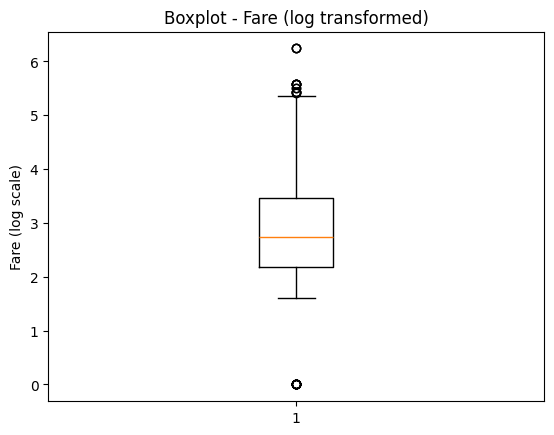

In [61]:
# Reduce outliers using log1p transformation

df['Fare_log_transform'] = np.log1p(df['Fare'])

plt.boxplot(df['Fare_log_transform'])
plt.title('Boxplot - Fare (log transformed)')
plt.ylabel('Fare (log scale)')
plt.show()

Attenuation by log transformation

As an alternative to the Z-score method, small and large values are now closer together (attenuation of large outliers). No values will be deleted.

**Conclusion**

Compared to the log transformation, the Z-score deletion method may lose important information, such as the proportion of wealthy passengers and class differentiation. The threshold value must be adjusted precisely depending on the issue at hand.

# Step 4: Data Transformation

Apply at least one transformation:

Encode a categorical feature (e.g., one-hot encoding), or

Create a new feature from existing ones (simple feature engineering), or

Apply binning to a numerical feature.

Explain what problem this transformation solves.

In [62]:
# One-Hot-Encoding
df_encoded = pd.get_dummies(df, columns=['Sex'], drop_first=False)
print("\nOne-Hot-Encoding\n", df_encoded[['Sex_female', 'Sex_male']].head()) # into 1/0 True/False

# Feature Engineering
df['Passenger_size'] = df['SibSp'] + df['Parch'] + 1
print("\nFeature Engineering\n",df['Passenger_size'].value_counts().sort_index())

# Binning
bins = [1, 12, 18, 79, 100]
labels = ['Kid', 'Teenager', 'Adult', 'Senior']

df['Age_Binning'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)
print("\nBinnig\n", df[['Age', 'Age_Binning']].head(15))


One-Hot-Encoding
    Sex_female  Sex_male
0       False      True
1        True     False
2        True     False
3        True     False
4       False      True

Feature Engineering
 Passenger_size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Binnig
      Age Age_Binning
0   22.0       Adult
1   38.0       Adult
2   26.0       Adult
3   35.0       Adult
4   35.0       Adult
5   28.0       Adult
6   54.0       Adult
7    2.0         Kid
8   27.0       Adult
9   14.0    Teenager
10   4.0         Kid
11  58.0       Adult
12  20.0       Adult
13  39.0       Adult
14  14.0    Teenager


Problem solving

1. One-hot encoding enables transformation into states.
2. Feature engineering enables grouping of travellers by group size.
3. Binning enables conversion into categories.

# Step 5: Feature Scaling

Select 2–3 numerical features.

Apply:

Standardization (Z-score)

Normalization (Min–Max scaling)

Compare the scaled values and explain:

When Z-score is preferred

When Min–Max scaling is preferred

In [63]:
features = ['Age', 'Fare']
X = df[features].copy()

# Standardisation Z-Score
z_scaler = StandardScaler()
z_X = z_scaler.fit_transform(X)
z_X = pd.DataFrame(z_X, columns=[f + '_z' for f in features])

# Normalisation (Min Max)
mm_scaler = MinMaxScaler()
mm_X = mm_scaler.fit_transform(X)
mm_X = pd.DataFrame(mm_X, columns=[f + '_mm' for f in features])

# compared
comparsion = pd.concat([X, z_X, mm_X], axis=1)
print(comparsion.head())

    Age     Fare     Age_z    Fare_z    Age_mm   Fare_mm
0  22.0   7.2500 -0.565736 -0.502445  0.271174  0.014151
1  38.0  71.2833  0.663861  0.786845  0.472229  0.139136
2  26.0   7.9250 -0.258337 -0.488854  0.321438  0.015469
3  35.0  53.1000  0.433312  0.420730  0.434531  0.103644
4  35.0   8.0500  0.433312 -0.486337  0.434531  0.015713


Explanation

Z-score is preferable when data is approximately symmetrical/normally distributed. Each variable is given equal weighting. Z-score is more better against outliers. Min-max scaling, on the other hand, is useful when dealing with limited ranges, e.g. 0–1, i.e. features are required within strict limits.